<style>
.custom-spacing {
    line-height: 0.5;
}
</style>

### <center>*LAPORAN UJIAN TENGAH SEMESTER*</center>
### <center>*METODE KOMPUTASI II*</center>
#### <center>Disusun Untuk Memenuhi Nilai Ujian Tengah Semester</center>
#### <center>Dosen Pengampu: 
#### <center>Dr. Muhammad Alimuddin Hamzah, M. Eng</center>
#### <center>Dr. Muhammad Taufiq Rafie, MT</center>
#### <center>Muhammad Farid Wajedy, S.Si, M.Si</center>

<div style="text-align:center;">
  <img src="https://www.unhas.ac.id/wp-content/uploads/2022/09/Logo-Resmi-Unhas-1.png" alt="Deskripsi Gambar" style="width:280px;">
</div>

### <center>*DISUSUN OLEH :*</center>
### <center>*KELOMPOK 3B*</center>

#### <center>GANI ABDAN SYAKURAN (H061241053)<center>
#### <center>HERMITA LESTARI           (H061241062)<center>
#### <center>ANDI TRI LESTARI (H061241055)<center>
#### <center>HARDIS HERO PRATAMA (H061241068)<center>
#### <center>WIRNA KHAIRUNNISA ASNAWI (H061241081)<center>
#### <center>DELA SHINTA SUMOMBA (H061241065)<center>
#### <center>MIFTA AL FADIL (H061241048)<center>
#### <center>ABEDNEGO R. PASORONG      (H061241063)<center>
#### <center>SYAUQI ASADUL HAQ (H061241052)<center>
#### <center>MUH. TENRI KAHFI GAMAL P (H061241084)</center>
#### <center>MUH.ARJUNA (H061241074)<center>
#### <center>HAIKAL PRATAMA (H061241058)<center>
#### <center>MACHYTA AHMAD (H061221020)<center>

### <center>*PROGRAM STUDI GEOFISIKA*</center>
### <center>*FAKULTAS MATEMATIKA DAN ILMU PENGETAHUAN ALAM*</center>
#### <center>*UNIVERSITAS HASANUDDIN*</center>
#### <center>*MAKASSAR*</center>
#### <center>*2026*</center>

<hr>

<table>
 <tr align=left><td><img align=left src="https://i.creativecommons.org/l/by/4.0/88x31.png">
 <td>Teks disediakan di bawah lisensi Creative Commons Attribution, CC-BY. Semua kode tersedia di bawah lisensi MIT yang disetujui FSF. (c) Kyle T. Mandli (dan Marc Spiegelman)</td>
</table>

Sebagian besar materi ini diadaptasi dari beberapa bab pertama [Larson and Bengzon: The Finite Element Method
Theory, Implementation,
and Applications](http://link.springer.com/book/10.1007%2F978-3-642-33287-6).


In [1]:
%matplotlib inline
import numpy
import matplotlib.pyplot as plt

# Metode Elemen Hingga: Pengantar

Metode Elemen Hingga (FEM) menyediakan metode lain untuk mengubah PDE kontinu menjadi sistem persamaan linier dan non-linier diskret, dan sangat populer dalam bidang Teknik serta Mekanika Padatan (meskipun metode ini bersifat umum). Elemen Hingga memiliki landasan matematis yang kaya dalam analisis fungsional serta berbagai aplikasi terspesialisasi yang sangat luas. Sudah tentu, topik ini beserta literaturnya sangat luas. Tujuan catatan ini hanyalah memberikan pengantar yang sangat mendasar tentang beberapa ide fundamental dalam Elemen Hingga dan implementasinya.


## Ruang Fungsi Berdimensi Hingga

Ide utama dalam Elemen Hingga adalah bahwa kita akan mengaproksimasi fungsi kontinu $f(x)$ sebagai kombinasi linier dari sejumlah berhingga fungsi basis

$$
    f_h(x) = \sum_{i=0}^N w_i \phi_i(x)
$$

di mana $\phi_i(x)$ adalah fungsi-fungsi basis dan $w_i$ adalah sekumpulan bobot. Kita telah melihat dekomposisi serupa pada metode spektral. Namun alih-alih menggunakan fungsi basis global seperti $\sin(kx)$ atau polinomial Chebyshev, kita akan (sebagian besar) menggunakan polinomial sepotong-sepotong (*piecewise polynomials*).



### Fungsi Linear Sepotong-Sepotong dalam 1-D (P1)

![](./images/P1_function_annotated_fig1.1LB.png)


Sebagai contoh, perhatikan fungsi linear sepotong-sepotong "sambung titik-titik" yang diilustrasikan di atas, di mana kita telah membagi interval $I=[x_0,x_5]$ menjadi 5 sub-interval atau "elemen" $e_i = [x_{i},x_{i+1}]$ dengan $i=1\ldots 4$. Pada setiap interval ini, fungsi $v_h$ adalah fungsi linear dari $x$ dan setiap segmen bersifat kontinu di tepi elemen. Gambar dimodifikasi dari Gambar 1.1 karya Larson dan Bengzon.


Meskipun $v_h(x)$ adalah fungsi kontinu yang dapat dievaluasi untuk setiap nilai $x$, jelas bahwa sebenarnya hanya ada 6 derajat kebebasan yang sesuai dengan nilai-nilai di titik simpul $\vec v = [v_0,v_1,v_2,v_3,\ldots,v_5]$. Dengan hanya mengubah 6 angka ini, kita dapat menghasilkan jumlah fungsi linear sepotong-sepotong yang tak terbatas pada triangulasi ini. Kita akan menyebut ruang fungsi berdimensi hingga ini sebagai $\cal V_h$, yang sepenuhnya dijelaskan oleh jaring elemen (*mesh*) dan interpolan di setiap elemen.


### Fungsi Basis Global

Untuk ruang fungsi diskret $\cal V_h$ mana pun, kita seharusnya dapat mendeskripsikan setiap fungsi $v_h\in \cal V_h$ dalam bentuk sekumpulan fungsi basis yang merentangi ruang tersebut. Dalam kasus ruang fungsi linear sepotong-sepotong 1-D, fungsi basis globalnya diberikan oleh "Fungsi Topi" (*Hat Functions*)

$$
\phi_i(x) = \left\{
\begin{array}{ll}
(x - x_{i-1})/\Delta x_{i-1}, & x\in e_{i-1} \\
(x_i - x)/\Delta x_{i}, & x\in e_{i} \\
0, & \text{otherwise} \\
\end{array}
\right.
$$


Yang memiliki sifat penting $\phi_i(x_j) = \delta_{ij}$. Fungsi topi yang umum ditunjukkan pada Gambar 1.2 dari Larson dan Bengson.
![](./images/P1_Hat_function_fig1.2LB.png)

Meskipun tidak sepenuhnya jelas, kita dapat mengonstruksi semua fungsi linear sepotong-sepotong dalam $\cal V_h$ sebagai kombinasi linier dari fungsi-fungsi topi ini, yaitu

$$
f_h(x) = \sum_{i=0}^5 w_i\phi_i(x)
$$


### Fungsi Basis Lokal

Untuk memperjelasnya, ada baiknya melihat bagaimana fungsi basis ini menginterpolasi $v$ pada satu elemen.

![](./images/P1LocalBases.png)

> **Gambar *3*: Definisi Fungsi Basis Global dan Lokal**


Perhatikan hanya bagian $v(x)$ yang terletak pada elemen $e_i$. Jelas bahwa satu-satunya fungsi basis global yang memiliki dukungan (*support*) pada elemen $e_i$ adalah $\phi_i(x)$ dan $\phi_{i+1}(x)$. Kita menyatakan bahwa pada elemen ini
$$
v(x) = v_i\phi_i(x) + v_{i+1}\phi_{i+1}(x)\quad\text{for}\quad x\in [x_i,x_{i+1}]
$$

Ini jelas berlaku di titik simpul karena sifat $\phi_i(x_j) = \delta_{ij}$.


Di antara simpul-simpul, kita mengharapkan $\phi_i$ dan $\phi_{i+1}$ memberikan interpolasi linear. Jika kita hanya mempertimbangkan *fungsi basis lokal* yang merupakan bagian dari $\phi_i$ dan $\phi_{i+1}$ dalam elemen $e_i$

\begin{align}
  N_0(x) & = (x_{i+1} - x)/(x_{i+1} - x_i)\\
  N_1(x) & = (x - x_i)/(x_{i+1} - x_i)\\
\end{align}

menjadi jelas bahwa ini hanyalah Polinomial Lagrange orde 1 yang menginterpolasi setiap fungsi linear pada interval $[x_i,x_{i+1}]$. Sebagai pemeriksaan, perhatikan bahwa jika $x* = x_i + t \Delta x_i$ dengan $s$ adalah jarak fraksional melintasi elemen dengan panjang $\Delta x_i = x_{i+1} - x_i$, maka
\begin{align}
  N_0(x*) & = (x_{i+1} - x_i -s \Delta x_i)/\Delta x_i = (1 - s)\\
  N_1(x*) & = (x_i + s \Delta x_i - x_i)/\Delta x_i = s\\
\end{align}

sehingga di dalam $e_i$
$$ 
   v(x) = v_i N_0(x) + v_{i+1}N_1(x) = v_i(1 - s)  + v_{i+1} s
$$
dengan $s\in[0,1]$

Jadi fungsi lengkap $v(x)$ di seluruh domain $\Omega = [x_0,x_5]$ hanyalah gabungan dari potongan-potongan linear lokal ini. Sepanjang pengantar ini, kita akan sering berpindah antara pandangan global dan pandangan elemen tergantung pada sudut pandang mana yang lebih mudah.


### Ruang Fungsi Polinomial Orde Lebih Tinggi

Ruang fungsi linear sepotong-sepotong sering disebut $P_1$, tetapi ada pilihan lain. Misalnya, ruang fungsi kuadratik sepotong-sepotong ($P_2$) memiliki sekumpulan fungsi basis lokal yang merupakan Polinomial Lagrange orde 2 dan memerlukan tiga derajat kebebasan per simpul. Fungsi basis global cukup dikonstruksi dari yang lokal. Gambar menunjukkan sebagian fungsi basis untuk $P_2$ yang berbeda untuk derajat kebebasan di pusat dan tepi elemen (gambar asli dari [Introduction to Finite Element Methods](http://hplgit.github.io/INF5620/doc/pub/sphinx-fem))

![](http://hplgit.github.io/INF5620/doc/pub/sphinx-fem/_images/mpl_fe_basis_p2_4e_lab.png)




## Interpolasi Fungsi $f(x)$ ke dalam $\cal V$

Diberikan sekumpulan fungsi basis $\phi_i(x)$ untuk ruang fungsi $\cal V$, jelas bahwa tidak semua fungsi dapat direpresentasikan secara tepat tanpa kesalahan dalam $\cal V$. Misalnya, diberikan fungsi mulus $f(x)$, pertanyaan yang muncul adalah bagaimana mengonstruksi aproksimasi $f_h(x) \in \cal V$ yang meminimalkan suatu ukuran kesalahan. Sebenarnya ada beberapa pendekatan. Aproksimasi paling sederhana adalah *interpolasi* atau *proyeksi* dari $f$ ke dalam $\cal V$, yang kita lambangkan sebagai $\pi f$, dan didefinisikan sebagai fungsi $\pi f \in \cal V$ sedemikian sehingga

$$
    \pi f (x) = \sum_{i=0}^N f(x_i)\phi(x)
$$


Mengingat sifat interpolasi polinomial Lagrange, jelas bahwa

$$
\pi f(x_j) = f(x_j)
$$

yaitu kedua fungsi memiliki kesalahan nol pada derajat kebebasan.


Gambar 1.3 dari Larson dan Bengzon menunjukkan interpolan linear dari fungsi $f$ pada satu elemen di interval $[x_0,x_1]$.
![](./images/f_interpolation_P1_01.png)


Gambar 1.4 dari Larson dan Bengzon menunjukkan interpolan linear dari fungsi $f$ ke dalam ruang fungsi linear sepotong-sepotong $\cal V$.

![](./images/f_interpolation_P1_02.png)


### Kesalahan Interpolasi

Secara umum biasanya akan ada kesalahan antara $f(x)$ dan interpolannya $\pi f(x)$. Namun untuk mengkuantifikasi kesalahan ini biasanya diperlukan pendefinisian suatu norma, dan seperti biasanya ada beberapa pilihan. Ternyata norma yang berguna dalam elemen hingga adalah norma $L^2$ dari suatu fungsi pada domain $\Omega$

$$
    ||f||_{L^2} = \left[ \int_\Omega f^2 dx\right]^{1/2}
$$

dan norma terkaitnya

$$
    ||f||_{L^2(I)} = \left[ \int_I f^2 dx\right]^{1/2}
$$

pada sub-interval $I$ (biasanya satu elemen).


Dengan definisi-definisi ini, dan perilaku interpolasi polinomial, cukup mudah untuk menetapkan estimasi berikut pada kesalahan interpolasi

* Kesalahan interpolasi pada satu elemen linear P1
$$ 
|| f - \pi f||_{L^2(I)} \leq C \Delta x^2||f''||_{L^2(I)}
$$
di mana $I = [x_i,x{i+1}]$, $\Delta x = x_{i+1} - x_{i}$, C adalah konstanta, dan $||f''||_{L^2(I)}$ adalah ukuran kelengkungan fungsi pada interval. Jika $\Delta x=0$ atau fungsinya linear pada interval tersebut, maka kesalahannya nol.

* Kesalahan interpolasi pada seluruh domain
Untuk fungsi polinomial sepotong-sepotong, kesalahan dalam interpolan ke dalam $\cal V$ adalah jumlah dari kesalahan-kesalahan pada tiap elemen, yaitu
$$ 
|| f - \pi f||^2_{L^2} \leq C \sum_{i=0}^N \Delta x_i^4||f''||^2_{L^2(I_i)}
$$


### Konvergensi

Dengan estimasi kesalahan ini, jelas bahwa interpolan konvergen ke fungsi kontinu dalam norma $L^2$ ketika $\Delta x\rightarrow 0$, yang masuk akal karena kita mengharapkan interpolan menjadi aproksimasi yang lebih baik terhadap $f$ untuk jaring yang semakin halus. Untuk fungsi $P_1$, kesalahannya konvergen sebagai $\Delta x^2$; interpolan orde lebih tinggi dari fungsi *mulus* seharusnya konvergen lebih cepat jika polinomial sepotong-sepotong orde lebih tinggi merupakan aproksimasi yang baik terhadap fungsi kontinu $f$.


## Proyeksi $L_2$ dari Fungsi $f(x)$ ke dalam $\cal V$

Meskipun interpolan $\pi f$ konvergen ke $f$ dalam norma $L^2$ ketika $\Delta x \rightarrow 0$, ternyata untuk $\Delta x$ yang tetap, interpolan tersebut bukanlah fungsi dalam $\cal V$ dengan kesalahan $L^2$ terkecil. Untuk masalah itu kita membutuhkan proyeksi ortogonal $L^2$, $P_h f$, yang ternyata merupakan fungsi unik $v_h\in\cal V$ yang meminimalkan $||f - v_h||_{L^2}$.
Gambar 1.6 dari Larson dan Bengzon menunjukkan proyeksi ortogonal dari $f$ ke dalam $\cal V$ untuk $f(x) = x\sin(\pi x)$

![](./images/f_projection_P1_01.png)



### Hubungan dengan Proyeksi Kuadrat Terkecil dalam Aljabar Linear

Sebelum kita mengembangkan perangkat untuk menghitung proyeksi ortogonal $L^2$ dari $f$ ke dalam $\cal V$, yaitu $P_h f$, ada baiknya meninjau secara singkat masalah proyeksi ortogonal terkait dari aljabar linear.

![](./images/projection_figure.png)



Perhatikan subruang 2-dimensi $\cal S$ dari $\mathbb R^3$ yang direntangi oleh dua vektor 3-D yang bebas linear $\boldsymbol{a}_1$ dan $\boldsymbol{a}_2$, yaitu

$$
\cal S = \mathrm{span}<\boldsymbol{a}_1,\boldsymbol{a}_2>
$$ 

Misalkan $\boldsymbol{b}$ adalah vektor ketiga yang tidak berada dalam $\cal S$. Masalahnya adalah menemukan titik $\boldsymbol{p} \in \cal S$ yang meminimalkan norma Euclidian 2 dari kesalahan $\boldsymbol{e} = \boldsymbol{b} - \boldsymbol{p}$ di mana $||\boldsymbol{e}||_2 = \sqrt{\boldsymbol{e}^T\boldsymbol{e}}$

Inspeksi gambar secara geometris menunjukkan bahwa kesalahan terpendek adalah dengan menemukan titik $\boldsymbol{p} = x_1\boldsymbol{a}_1 + x_2\boldsymbol{a}_2$ sedemikian sehingga $\boldsymbol{e}$ ortogonal terhadap bidang $\cal S$. Jika kita mendefinisikan matriks

$$
A = \begin{bmatrix}
    \boldsymbol{a}_1 & \boldsymbol{a}_2
    \end{bmatrix}
$$

yang kolomnya adalah vektor $\boldsymbol{a}_1$ dan $\boldsymbol{a}_2$, maka $\boldsymbol{p} = A\boldsymbol{x}$ di mana

$$
\boldsymbol{x} = \begin{bmatrix}
    x_1\\
    x_2
    \end{bmatrix}
$$

Agar $\boldsymbol{e}$ ortogonal terhadap setiap vektor dalam $\cal S$, cukup jika ia ortogonal terhadap vektor basis $\boldsymbol{a}_1$ dan $\boldsymbol{a}_2$. Sehingga syarat ortogonalitas adalah

$$
    \boldsymbol{a}_i^T\boldsymbol{e} = 0
$$

untuk $i=1,2$. Ini ekuivalen dengan pernyataan $A^T\boldsymbol{e}=\boldsymbol{0}$ (atau bahwa kesalahan berada dalam ruang nol kiri dari $A$).

Tetapi
$$\begin{aligned}
    A^T\boldsymbol{e} & = A^T(\boldsymbol{b} - \boldsymbol{p}) \\
                      & = A^T(\boldsymbol{b} - A\boldsymbol{x}) \\
                      & = \boldsymbol{0}
\end{aligned}$$

atau solusi kuadrat terkecil memerlukan penyelesaian Persamaan Normal

$$
    A^TA\boldsymbol{x} = A^T\boldsymbol{b}
$$

(meskipun cara numerik yang lebih baik untuk menyelesaikan ini adalah menggunakan faktori QR yang merupakan aplikasi lain dari proyeksi ortogonal)

Dengan solusi $\boldsymbol{x}$, proyeksinya cukup berupa $\boldsymbol{p} = A\boldsymbol{x}$


### Proyeksi Ortogonal Fungsi ke dalam Ruang Fungsi Diskret

Jika Anda memahami masalah sebelumnya dari aljabar linear, Anda akan menyadari bahwa proyeksi ortogonal suatu fungsi ke dalam ruang fungsi diskret pada dasarnya adalah masalah yang sama dengan perangkat yang sedikit berbeda.

Masalahnya dapat dinyatakan:

Diberikan fungsi kontinu $f(x)$ dan ruang fungsi diskret $\cal V_h$, temukan fungsi $P_h f\in \cal V_h$ yang meminimalkan $ || f - P_h f||_{L^2}$.


Sekali lagi, kita dapat mengonstruksi masalah secara geometris. Pertama, jika $P_h f \in \cal V_h$ maka kita dapat menuliskannya dalam bentuk fungsi basis dari $\cal V_h$, yaitu

$$
    P_h f(x)  = \sum_{j=0}^N w_j\phi_j(x)
$$

Selanjutnya kita mengonstruksi residual (atau kesalahan) sebagai

$$ 
    r(x) = f(x) - P_h f(x) 
$$
dan mensyaratkan bahwa residual tersebut "ortogonal" terhadap setiap fungsi $v_h\in \cal V_h$, di mana kita mendefinisikan ortogonalitas fungsi terhadap norma $L^2$ dengan cara biasa. Artinya, kita katakan bahwa $f$ dan $g$ adalah fungsi ortogonal jika

$$
    \int_\Omega fg dx = 0
$$

Oleh karena itu, agar $r$ ortogonal terhadap setiap fungsi $v_h\in \cal V_h$, hanya diperlukan bahwa ia ortogonal terhadap setiap fungsi basis dari $\cal V_h$. Untuk ruang fungsi berdimensi hingga, masalahnya menjadi: temukan $P_h f \in \cal V_h$ sedemikian sehingga

$$ 
    \int_\Omega \phi_i(x) r(x) dx = 0
$$ 
untuk semua $i=0,\ldots,N$.

Menggunakan definisi kita untuk $r(x)$ dan $P_h f(x)$, masalahnya menjadi: temukan vektor bobot $\boldsymbol{w} = [ w_0, w_1,\ldots, w_N]^T$ sedemikian sehingga

$$
    \int_\Omega \phi_i(x)\sum_{j=0}^N w_j\phi_j(x) dx = \int_\Omega \phi_i(x) f(x) dx
$$ 
untuk semua $i=0,\ldots,N$.

Sekarang ruas kanan persamaan ini adalah sekumpulan $N$ bilangan yang masing-masing mendeskripsikan hasil kali dalam $L^2$ dari $f$ dengan setiap fungsi basis. Dengan mendefinisikan

$$
    \tilde{f}_i = \int_\Omega \phi_i(x) f(x) dx\quad i=0,\ldots,N
$$
ruas kanan tersusun menjadi vektor $\tilde{\boldsymbol{f}}\in \mathbb R^{N+1}$.

Ruas kiri sedikit lebih rumit, tetapi kita dapat menukar penjumlahan dan integral untuk menulis ulang ruas kiri sebagai

$$
\int_\Omega \phi_i(x)\sum_{j=0}^N w_j\phi_j(x) dx = \sum_{j=0}^N w_j\int_\Omega \phi_i(x)\phi_j(x) dx
$$

Sekarang integral tertentu terakhir adalah sekumpulan bilangan dengan dua indeks

$$
    M_{ij} = \int_\Omega \phi_i(x)\phi_j(x) dx
$$

yang mendefinisikan entri dari "Matriks Massa" $M$.

Dengan demikian masalah proyeksi sebenarnya tereduksi menjadi pernyataan aljabar linear
$$
    \sum_{j=0}^N M_{ij}w_j = \tilde{f}_i
$$
atau dalam notasi matriks-vektor, selesaikan
$$
    M\boldsymbol{w} = \tilde{\boldsymbol{f}}
$$
untuk $\boldsymbol{w}$, kemudian $P_h f(x)$ didefinisikan oleh bobot dan fungsi basis.


![](./images/FEM_projection_assembly.png)

Gambar 9 menunjukkan semua komponen yang diperlukan untuk menyusun matriks massa $M$ dan vektor beban $\tilde{\boldsymbol{f}}$


### Struktur Matriks Massa

Untuk memahami struktur matriks massa, berguna untuk memeriksa gambar di atas.

Diberikan interval 1-D dengan $N$ elemen, Matriks Massa $M$ adalah matriks berukuran $N+1\times N+1$ yang komponennya diberikan oleh

$$
    M_{ij} = \int_\Omega \phi_i(x)\phi_j(x) dx
$$

Jika fungsi basis bersifat ortonormal (misalnya sinus dan kosinus atau polinomial Chebyshev), Matriks Massa akan sama dengan Identitas $I$. Namun, jika fungsi basis adalah fungsi topi, pemeriksaan gambar 9 menunjukkan bahwa matriks ini seharusnya jarang (*sparse*) karena fungsi basis yang tidak berbagi dukungan yang sama akan memiliki $M_{ij}=0$. Untuk kasus masalah 1-D dalam $P_1$, jelas bahwa Matriks Massa sebenarnya harus tridiagonal karena satu-satunya elemen tak-nol akan muncul dari interaksi antara fungsi basis $\phi_i$ dan dua tetangga terdekatnya $\phi_{i-1}$ dan $\phi_{i+1}$

Khususnya, baris ke-$i$ dari $M$ akan memiliki tiga entri tak-nol

$$\begin{aligned}
    M_{i,i-1} &= \int_\Omega \phi_{i}\phi_{i-1} dx = \int_{x_{i-1}}^{x_i} \phi_{i}\phi_{i-1} dx \\
    M_{i,i} &= \int_\Omega \phi_{i}\phi_{i} dx = \int_{x_{i-1}}^{x_{i+1}} \phi_{i}\phi_{i} dx \\
    M_{i,i+1} &= \int_\Omega \phi_{i}\phi_{i+1} dx = \int_{x_i}^{x_{i+1}} \phi_{i}\phi_{i+1} dx \\
\end{aligned}$$

Perhatikan bahwa suku pertama seluruhnya dikontribusikan oleh elemen $e_{i-1}$, suku terakhir oleh elemen $e_i$, dan entri diagonal sebenarnya dapat dibagi menjadi dua bagian

$$
    M_{i,i} = \int_{x_{i-1}}^{x_{i}} \phi_{i}\phi_{i} dx + \int_{x_{i}}^{x_{i+1}} \phi_{i}\phi_{i} dx
$$

yang sesuai dengan kontribusi dari kedua elemen $e_{i-1}$ dan $e_i$. Untuk fungsi topi $P_1$ sederhana, kita sebenarnya dapat menghitung entri-entri ini secara analitis (meskipun untuk masalah yang lebih rumit atau matriks beban, kita mungkin ingin menggunakan kuadratur numerik).

Jika kita hanya mempertimbangkan suku pertama dan menggunakan definisi $\phi_{i-1}$ dan $\phi_i$

$$
    M_{i,i-1} = \int_{x_{i-1}}^{x_i} \frac{x_{i} - x}{\Delta x_{i-1}} \frac{x - x_{i-1}}{\Delta x_{i-1}} dx 
$$

yang mudah diintegralkan, tetapi lebih mudah dilakukan jika kita terlebih dahulu melakukan transformasi affine

$$
 x(t) = x_{i-1} + s \Delta x_{i-1}
$$

di mana lagi-lagi $s\in [0,1]$ adalah jarak fraksional melintasi elemen $e{i-1}$ ($s$ juga dikenal sebagai koordinat elemen lokal). Dengan transformasi ini dan $dx = \Delta x_{i-1} ds$, integral di atas disederhanakan menjadi

$$
        M_{i,i-1} = \Delta x_{i-1}\int_{0}^{1} ( 1- s) s ds = \Delta x_{i-1} \left.\left( \frac{s^2}{2} - \frac{s^3}{3}\right)\right|_0^1 = \frac{\Delta x_{i-1}}{6}
$$ 

Dengan pendekatan yang sama kita dapat mengevaluasi suku-suku yang tersisa
$$\begin{aligned}
M_{i,i} &= \Delta x_{i-1}\int_{0}^{1} s^2 ds  + \Delta x_i\int_{0}^{1} (1 - s)^2 ds = \frac{\Delta x_{i-1}}{3} + \frac{\Delta x_i}{3}\\
M_{i,i+1} & = \Delta x_i\int_{0}^{1} s(1-s) ds = \frac{\Delta x_i}{6}
\end{aligned}$$

sehingga stensil untuk satu baris matriks massa adalah

$$
M_i = \begin{bmatrix}
   \frac{\Delta x_{i-1}}{6}  & \frac{\Delta x_{i-1}}{3} + \frac{\Delta x_i}{3} & \frac{\Delta x_i}{6}
    \end{bmatrix}
$$

dan Matriks Massa Global terlihat seperti
$$
    M = \begin{bmatrix}
    \frac{\Delta x_0}{3}  & \frac{\Delta x_0}{6} & & & & \\
    \frac{\Delta x_0}{6}  & \frac{\Delta x_0}{3} + \frac{\Delta x_1}{3} & \frac{\Delta x_1}{6} & & & \\
    &\frac{\Delta x_1}{6}  & \frac{\Delta x_1}{3} + \frac{\Delta x_2}{3} & \frac{\Delta x_2}{6}  & & \\
    & & \ddots & \ddots & \ddots & \\
    & & &   &  \frac{\Delta x_N}{6} & \frac{\Delta x_N}{3}
    \end{bmatrix}
$$


### Mekanisme: Perakitan Per Elemen

Meskipun memungkinkan untuk merakit matriks massa global seperti yang dijelaskan di atas, pendekatan yang lebih baik adalah dengan melakukan perulangan pada setiap elemen dan menghitung kontribusi lokal setiap elemen ke matriks massa global. Untuk memulai, kita dapat menguraikan $M$ menjadi jumlah matriks blok yang lebih sederhana

$$
M = \begin{bmatrix}
\frac{\Delta x_0}{3}  & \frac{\Delta x_0}{6} & &  \\
\frac{\Delta x_0}{6}  & \frac{\Delta x_0}{3}  & & \\ 
&&& \\
&&& \\
&&& \\
&&& 
\end{bmatrix} +
\begin{bmatrix}
&&& \\
& \frac{\Delta x_1}{3}  & \frac{\Delta x_1}{6}   & \\ 
& \frac{\Delta x_1}{6}  & \frac{\Delta x_1}{3}  &  \\
&&& \\
&&& \\
&&& 
\end{bmatrix} + \ldots +
\begin{bmatrix}
&&& \\
&&& \\
&&& \\
&&& \\
& & \frac{\Delta x_N}{3}  & \frac{\Delta x_N}{6} \\
& &\frac{\Delta x_N}{6}  & \frac{\Delta x_N}{3}  
\end{bmatrix} 
$$

atau

$$
M = M^{e_0} + M^{e_1} + \ldots + M^{e_N}
$$

di mana

$$
  M^{e_i} = \frac{\Delta x_i}{6}\begin{bmatrix}
  2 & 1\\
  1 & 2
  \end{bmatrix}
  $$
  
  adalah Matriks Massa elemen lokal untuk elemen $e_i$. Pemeriksaan Gambar 3 menunjukkan bahwa kita dapat mendeskripsikan matriks massa elemen sepenuhnya dalam bentuk fungsi basis lokal $N_0(t)$ dan $N_1(t)$ dalam sistem koordinat lokal sebagai
  
$$
  M^{e_i} = \Delta x_i\begin{bmatrix}
  \int_0^1 N_0^2 dt & \int_0^1 N_0N_1 dt \\
  \int_0^1 N_0N_1 dt & \int_0^1 N_1^2 dt 
\end{bmatrix}
$$

dan setiap entri ini sesuai dengan sebagian (atau keseluruhan) entri dalam matriks massa global

$$
  M^{e_i} = \begin{bmatrix}
  M_{i,i} & M_{i,i+1} \\
  M_{i+1,i} & M_{i+1,i+1} 
\end{bmatrix}
$$

Jadi algoritma keseluruhannya adalah
* Lakukan perulangan pada elemen $i=0,\ldots,N$
* Hitung Matriks Massa lokal $M^{e_i}$
* Masukkan/tambahkan ke dalam Matriks Massa Global

Proses serupa digunakan untuk merakit vektor beban $\tilde{\boldsymbol{f}}$ dengan
* Lakukan perulangan pada elemen $i=0,\ldots,N$
* Hitung kontribusi elemen ke vektor beban

$$
    \tilde{\boldsymbol{f}}^{e_i} = \begin{bmatrix}
        \int_{x_{i-1}}^{x_i} N_0(x)f(x) dx \\
        \int_{x_{i-1}}^{x_i} N_1(x)f(x) dx 
        \end{bmatrix} = \begin{bmatrix}
        \tilde{f}_i \\
        \tilde{f}_{i+1} 
        \end{bmatrix}
$$
* Masukkan/Tambahkan ke dalam Vektor Beban Global




### Konvergensi/Optimalitas

Untuk pembahasan selanjutnya...


# Menyelesaikan Persamaan Poisson 1-D menggunakan FEM


Masalah proyeksi sebenarnya menyediakan sebagian besar perangkat yang diperlukan untuk menggunakan metode FEM dalam menyelesaikan PDE. Di sini kita akan mempertimbangkan masalah nilai batas 2-titik paling sederhana dalam 1-D
$$
    -\frac{d^2 u}{dx^2} = f(x)\quad \mathrm{on} \quad \Omega = [0,1]
$$
dengan syarat batas Dirichlet
$$
    u(0) = u(1) = 0
$$

dan jika kita menyederhanakannya lebih lanjut dengan $f(x)=1$, kita mendapatkan masalah MMS yang mudah dengan solusi yang diketahui

$$
    u(x) = \frac{1}{2}x(1 - x)
$$

Bagian-bagian berikut akan memberikan resep singkat untuk mengonstruksi masalah Elemen Hingga Galerkin


## Memilih Ruang Fungsi (Jaring + Elemen)

Untuk memulai, kita akan memilih ruang fungsi $\cal V$ untuk mengaproksimasi fungsi diskret kita. Pertama, kita akan membagi interval satuan dengan $N$ elemen berukuran $h_j$ (yang tidak harus sama). Kemudian, karena kita sudah akrab dengannya, kita akan mengaproksimasi solusi kita dalam $P_1$ sebagai fungsi linear sepotong-sepotong, yaitu

$$
    u_h = \sum_{j=0}^N w_j\phi_j(x)
$$

di mana $\phi(x)$ adalah basis fungsi topi standar untuk $P_1$.

Ini mungkin tampak sebagai pilihan yang aneh mengingat bahwa **bentuk kuat** dari PDE mencari fungsi yang turunan keduanya konstan di mana-mana, sementara turunan kedua dari fungsi $P_1$ adalah sekumpulan fungsi delta pada tepi elemen (aduh) (dan bahkan turunan pertamanya adalah fungsi konstanta sepotong-sepotong, tetapi itu setidaknya berada dalam $L^2$).

Meskipun demikian, seperti yang akan kita lihat, ini adalah pilihan yang sangat baik untuk masalah ini (seperti biasa dalam beberapa Norma).



## Membuat Bentuk Lemah (*Weak Form*)

Seperti yang dinyatakan, fungsi diskret $u_h(x)$ tidak dapat menjadi solusi dari (Pers. \ref{strongform}), namun untuk fungsi apa pun, kita selalu dapat menghitung residual dengan mensubstitusikannya ke dalam bentuk kuat, yaitu

$$
    r(x) = -\frac{d^2 u_h}{dx^2} - f(x).
$$

Tentu saja jika $u_h$ adalah solusi dari (Pers. \ref{strongform}), maka $r(x)=0$, tetapi mengingat ruang fungsi tertentu $\cal V$ kita tidak dapat mengandung solusi kuat, kita dapat mengajukan masalah yang lebih umum:

> Temukan $u_h$ dalam $\cal V$ yang meminimalkan $||r||_{L^2}$.

Dengan analogi pada masalah proyeksi, kita dapat merumuskan ulang masalah tersebut sebagai

> Temukan $u_h$ dalam $\cal V$ sedemikian sehingga
> $$
\int_\Omega v r dx =0
$$
> untuk semua $v$ dalam $\cal V$.

Dengan kata lain, temukan solusi yang residualnya ortogonal dalam norma $L^2$ terhadap ruang fungsi linear sepotong-sepotong pada jaring.

Dengan mengembangkan residual, masalahnya menjadi

> Temukan $u_h$ dalam $\cal V$ sedemikian sehingga
> $$
    - \int_\Omega v \frac{d^2 u_h}{dx^2} dx  = \int_\Omega vf dx
$$
> untuk semua $v$ dalam $\cal V$.


### Beberapa Terminologi

Persamaan $\eqref{eq:weak_form}$ dikenal sebagai **bentuk lemah** atau **bentuk variasional** dari masalah ini. Selain itu, ada terminologi umum lain yang muncul dalam FEM. Secara umum kita menyebut

- $u_h$ sebagai *fungsi percobaan* (*trial function*) (yaitu fungsi yang kita coba dalam residual)
- $v$ adalah *fungsi uji* (*test function*) (yaitu fungsi apa pun dalam $\cal V$ yang kita uji ortogonalitasnya)
- Ruas kiri Pers. \eqref{eq:wf}
$$
    a(u_h,v) = -\int_\Omega v \frac{d^2 u_h}{dx^2} dx
$$
adalah **bentuk bilinear** $a(u,v)$ yang mengambil dua fungsi $u$ dan $v$ sebagai argumen dan bersifat linear dalam kedua argumen
- Ruas kanan Pers. \eqref{eq:wf}
$$
    L(v) = \int_\Omega vf dx 
$$
adalah **bentuk linear** $L(v)$ yang menghasilkan skalar untuk setiap fungsi $v$
- Singkatan yang sering digunakan untuk mendeskripsikan masalah variasional ini adalah
$$
    a(u,v) = L(v)
$$


### Integrasi per Bagian (*Integration by Parts*)

Bentuk bilinear pada ruas kiri $Pers \eqref{eq:wf}$ masih agak bermasalah (terutama jika $u_h$ berada dalam $P_1$), tetapi salah satu fitur indah dari bentuk variasional adalah bahwa kita selalu dapat menerapkan integrasi per bagian untuk memindahkan sebagian turunan dari fungsi percobaan ke fungsi uji. Mengingat bahwa

$$
    \frac{d^2 u_h}{dx^2} = \frac{d}{dx}\frac{du_h}{dx}
$$

dan aturan produk standar memberikan
$$
    \frac{d}{dx} \left(v \frac{du_h}{dx}\right) = v\frac{d^2 u}{dx^2} + \frac{dv}{dx}\frac{du_h}{dx}
$$

Maka

$$\begin{aligned}
a(u_h,v) &= -\int_\Omega v \frac{d^2 u_h}{dx^2} dx \\
        &= \int_\Omega \frac{dv}{dx}\frac{du_h}{dx} dx - \int_\Omega \frac{d}{dx} \left(v \frac{du_h}{dx}\right) dx \\
        &= \int_\Omega \frac{dv}{dx}\frac{du_h}{dx} dx - \left. v \frac{du_h}{dx}\right|_{\partial\Omega}
\end{aligned}$$

di mana suku terakhir bergantung pada fungsi uji dan turunan pertama dari $u_h$ yang dievaluasi pada batas domain (sehingga syarat batas Neumann atau fluks sangat alami dimasukkan dalam formulasi Elemen Hingga).

Jika kita mengabaikan suku permukaan untuk saat ini, integrasi per bagian telah mengubah bentuk bilinear menjadi

$$
    a(u_h,v) = \int_\Omega \frac{dv}{dx}\frac{du_h}{dx} dx 
$$ 

yang hanya bergantung pada gradien dari fungsi uji dan fungsi percobaan, yang dalam $P_1$ bersifat konstanta sepotong-sepotong.




### Bentuk Lemah untuk Ruang Fungsi Berdimensi Hingga

Semua terminologi dan ide di atas berlaku untuk ruang fungsi berdimensi tak hingga maupun berdimensi hingga. Namun untuk ruang fungsi berdimensi hingga dengan jumlah fungsi basis yang tetap, berbagai bentuk linear dan bilinear sebenarnya tereduksi menjadi operator aljabar linear. Kita telah melihat hal ini dalam kasus masalah proyeksi dan struktur masalahnya sama untuk Poisson.

Kita mulai dengan mengekspresikan fungsi percobaan kita dalam bentuk fungsi basis
$$
    u_h(x) = \sum_{j=0}^N w_j\phi_j(x)
$$

dan memilih sebagai fungsi uji kita masing-masing fungsi basis secara berurutan sehingga masalah variasional $a(v,u_h)=L(v)$ sebenarnya menjadi

- Temukan $\boldsymbol{w}\in R^{N+1}$ sedemikian sehingga

$$
    \int_\Omega \frac{d\phi_i}{dx} \sum_{j=0}^N w_j \frac{d\phi_i}{dx} dx = \int_\Omega \phi_i f dx
$$

atau dengan menukar integral dan penjumlahan kita dapat menulis masalah sebagai

$$
     \sum_{j=0}^N w_j \int_\Omega \frac{d\phi_i}{dx}\frac{d\phi_i}{dx} dx = \int_\Omega \phi_i f dx
$$

atau

$$
    \sum_{j=0}^N A_{ij}w_j = \tilde{f}_i
$$

di mana

$$ 
    A_{ij} = \int_\Omega \frac{d\phi_i}{dx}\frac{d\phi_i}{dx} dx \quad \tilde{f}_i = \int_\Omega \phi_i f dx
$$

atau cukup

$$
A\boldsymbol{w} = \tilde{\boldsymbol{f}}
$$

di mana $A$ adalah **Matriks Kekakuan** (*Stiffness Matrix*) dan $\tilde{\boldsymbol{f}}$ adalah **vektor beban** (*load vector*). (Catatan: banyak terminologi elemen hingga berasal dari penerapannya pada masalah elastisitas dalam rekayasa, sehingga kata-kata seperti kekakuan dan beban telah menjadi bagian dari nomenklatur. Meskipun benar bahwa nilai eigen dari A untuk Poisson dapat menyebabkan masalah kaku dalam pengaturan ODE, hal ini tidak ada hubungannya dengan nama Matriks Kekakuan.)

Dengan kata lain, bentuk lemah dari PDE Pers. \eqref{strongform} bertransformasi menjadi $A\boldsymbol{w} = \tilde{\boldsymbol{f}}$ dengan cara yang sama seperti bentuk lemah dari masalah proyeksi $u_h = f$ bertransformasi menjadi $M\boldsymbol{w} = \tilde{\boldsymbol{f}}$ di mana $M$ adalah matriks massa dan vektor beban persis sama.


## Perakitan (*Assembly*)

Perakitan matriks kekakuan global dan vektor beban global dilakukan persis sama seperti pada masalah proyeksi (dan faktanya vektor beban sama dalam kedua masalah). Satu-satunya perbedaan kecil adalah bahwa matriks kekakuan sekarang mengandung turunan dari fungsi basis, bukan fungsi basis itu sendiri. Namun sangat mudah untuk mengerjakan semua detailnya untuk elemen $P_1$.

Sekali lagi kita mulai dengan merakit matriks kekakuan **elemen**

$$
  A^{e_i} = \begin{bmatrix}
  \int_{x_i}^{x_{i+1}} \frac{dN_0}{dx}^2 dx & \int_{x_i}^{x_{i+1}} \frac{dN_0}{dx}\frac{dN_1}{dx} dx \\
  \int_{x_i}^{x_{i+1}} \frac{dN_0}{dx}\frac{dN_1}{dx} dx & \int_{x_i}^{x_{i+1}} \frac{dN_1}{dx}^2 dx \\
\end{bmatrix}
$$

di mana
$$
    N_0(x) = \frac{x_{i+1} - x}{\Delta x_i} \quad N_1(x) = \frac{x - x_i}{\Delta x_i}
$$
adalah fungsi basis elemen lokal (atau fungsi bentuk) yang dalam hal ini hanyalah Polinomial Lagrange orde 1.

Di bawah transformasi affine standar $x = x_{i} + t h_i$, kita mengubah ini lagi ke koordinat lokal sehingga
$$
    N_0(t) = 1 - t \quad N_1(t) = t
$$

Dan terapkan

$$
    \frac{dN_i}{dx} = \frac{dN_i}{dt}\frac{dt}{dx} = \frac{1}{\Delta x_i}\frac{dN_i}{dt}
$$

sehingga misalnya suku pertama dalam matriks kekakuan elemen menjadi
$$
    A^{e_i}_{00} = \frac{1}{\Delta x_i}\int_0^1 dt = \frac{1}{\Delta x_i}
$$

dan matriks kekakuan elemen menjadi

$$
    A^{e_i} = \frac{1}{\Delta x_i}\begin{bmatrix}
    1 & -1 \\
    -1 & 1 \\
    \end{bmatrix}
$$

Perakitan matriks kekakuan global dilakukan dengan cara yang sama dengan stensil untuk titik interior
$$
M_i = \begin{bmatrix}
   -\frac{1}{\Delta x_{i-1}}  & \frac{1}{\Delta x_{i-1}} + \frac{1}{\Delta x_i} & \frac{1}{\Delta x_i}
    \end{bmatrix}
$$

yang untuk jaring beraturan dengan $h_0,\ldots,h_N = h$ adalah
$$
M_i = \frac{1}{\Delta x}\begin{bmatrix}
   -1 & 2 & -1
    \end{bmatrix}
$$

yang merupakan stensil beda hingga terpusat orde dua klasik kita untuk turunan kedua, dan Matriks Massa Global terlihat cukup familiar sebagai
$$
    M = \frac{1}{\Delta x}\begin{bmatrix}
    1  & -1 & & & & \\
    -1 & 2 & -1 & & & \\
    &-1  & 2 & -1  & & \\
    & & \ddots & \ddots & \ddots & \\
    & & &   &  -1 & 2
    \end{bmatrix}
$$

Dengan demikian, setidaknya untuk Poisson dengan pemaksaan konstan dan jaring 1-D, Elemen Hingga Galerkin $P_1$ memberikan diskretisasi yang persis sama dengan beda hingga orde dua.


## Syarat Batas (*Boundary Conditions*)

Untuk melengkapi deskripsi bentuk diskret dari masalah PDE eliptik ini, kita perlu menerapkan syarat batas. Dalam kasus syarat batas Fluks Neumann, ini dengan mudah dimasukkan ke dalam perakitan bentuk lemah. Integrasi per bagian dari bentuk bilinear menghasilkan suku tambahan
$$
\left. v \frac{du_h}{dx}\right|_{\partial\Omega}
$$

yang kita abaikan sejauh ini, tetapi konsisten dengan syarat tanpa-fluks $\frac{du_h}{dx}=0$. Syarat Neumann yang lebih umum menyatakan bahwa $\frac{du_h}{dx}$ diketahui pada batas, misalnya gradiennya adalah suatu konstanta yang diketahui $\frac{du_h}{dx}=\alpha$. Dalam hal ini kita cukup menggantikan $\alpha$ untuk gradien dalam suku di atas yang sekarang hanya merupakan fungsi dari fungsi uji $v$ dan dievaluasi serta ditambahkan ke vektor beban.

Syarat batas Dirichlet (seperti biasa) agak lebih rumit dan dapat diimplementasikan dengan beberapa cara, mirip dengan bagaimana hal itu dilakukan dalam masalah beda hingga. Cara yang paling bersih adalah dengan mencatat bahwa jika batas memiliki nilai yang diketahui, derajat kebebasan tersebut sebenarnya tidak berada dalam ruang fungsi dan kita cukup mulai menyelesaikan dari titik interior pertama dan menyesuaikan ruas kanan seperlunya. Namun saat merekonstruksi fungsi, kita perlu mengingat untuk memasukkan nilai yang tepat pada batas.

Pendekatan lain termasuk merakit masalah seperti sebelumnya dan kemudian sebagai langkah pasca-perakitan, memodifikasi matriks untuk menempatkan angka 1 pada diagonal, menolkan sisa baris, dan memasukkan nilai yang sesuai dalam vektor beban. Namun hal ini sering dapat menyebabkan hilangnya simetri dari matriks kekakuan, sehingga pendekatan yang lebih baik adalah menolkan baik baris maupun kolom dan menyesuaikan ruas kanan.


# Perangkat Lunak Lanjutan untuk Pemodelan Elemen Hingga

Meskipun tidak sulit untuk menulis skrip Python sederhana yang mengimplementasikan semua langkah untuk menyelesaikan masalah Poisson dalam 1-D dengan elemen linear, menulisnya dengan cara yang dapat diperluas dan modular sehingga dapat dikembangkan ke dimensi yang lebih tinggi, elemen yang berbeda, solver yang berbeda, dan seterusnya, adalah tugas yang menakutkan. Untungnya, orang-orang yang lebih cerdas dari saya telah mengembangkan berbagai pustaka dan aplikasi FEM baik komersial maupun sumber terbuka. Saya mencantumkan beberapa yang paling populer di akhir catatan ini.

Namun, salah satu yang sangat menarik, baik secara matematis maupun komputasional, adalah [FEnICS](http://fenicsproject.org) dari fenicsproject.org.


![](http://fenicsproject.org/_static/fenics_banner.png)

(oke gambar itu terlalu besar tapi Jupyter tampaknya tidak membiarkan saya mengubah ukuran gambar)

Bagaimanapun, proyek FEniCS menyediakan seperangkat pustaka dan alat komputasional untuk perancangan dan eksplorasi cepat masalah berbasis PDE menggunakan Metode Elemen Hingga. Deskripsi singkat fitur-fitur menariknya adalah
- Menyediakan antarmuka C++ dan python ke pustaka intinya
- Mencakup bahasa tingkat tinggi menyerupai python (UFL, bahasa bentuk terpadu) untuk deskripsi bentuk lemah yang tampak seperti integral yang kita tulis di sini. Secara khusus UFL mendukung
-- berbagai elemen kontinu dan diskontinu (lihat [Tabel Periodik Elemen Hingga](http://femtable.org/))
-- operator vektor dan tensor tingkat tinggi (Div, Grad, Curl)
-- Diferensiasi Otomatis dari Bentuk (sangat berguna untuk masalah non-linear)
- FFC: Kompiler Bentuk FEniCS, sebuah program python yang mengambil UFL dan melakukan pembuatan kode otomatis untuk membuat C++ yang dapat dikompilasi secara khusus untuk perakitan bentuk-bentuk rumit pada Elemen.
- DOLFIN: kumpulan pustaka utama untuk menangani jaring, perakitan, solver, dan IO/visualisasi. Khususnya memiliki beberapa backend solver ke pustaka solver lanjutan seperti [PETSc](https://www.mcs.anl.gov/petsc/) dan [Trilinos](https://trilinos.org/)

Tetapi sebenarnya lebih mudah untuk melihat demo Python untuk memahami cara kerjanya. Potongan kode berikut dimodifikasi dari salah satu demo mereka yang terdokumentasi dengan baik untuk menyelesaikan persamaan Poisson tetapi dimodifikasi ke masalah 1-D yang telah kita diskusikan.


In [ ]:
"""This demo program solves Poisson's equation in 1-D

    - d^2 u/ dx^2  = f(x)

on the unit interval with source f given by

    f(x) = 1

and homogeneous Dirichlet boundary conditions given by

    u(0)=u(1) = 0        for x = 0 or x = 1
"""

# Modified from demo_poisson.py from the FEniCS demos


# Begin demo

from dolfin import *

# Create mesh and define function space
mesh = UnitIntervalMesh(32)
V = FunctionSpace(mesh, "Lagrange", 1)

# Define Dirichlet boundary (x = 0 or x = 1)
def boundary(x):
    return x[0] < DOLFIN_EPS or x[0] > 1.0 - DOLFIN_EPS

# Define boundary condition
u0 = Constant(0.0)
bc = DirichletBC(V, u0, boundary)

# Define variational problem
u = TrialFunction(V)
v = TestFunction(V)
f = Constant(1.)
a = v.dx(0)*u.dx(0)*dx
L = f*v*dx 

# Compute solution
u = Function(V)
solve(a == L, u, bc)

# Save solution in VTK format
file = File("poisson.pvd")
file << u


# Plot solution
plot(u, interactive=True)


Dan berikut adalah masalah yang sama tetapi dengan syarat batas Neumann pada ruas kanan sedemikian sehingga $du_h/dx = \alpha$, yang cukup menambahkan satu suku lagi ke dalam bentuk Linear yang berasal dari integral permukaan dari bentuk bilinear


Solving linear variational problem.


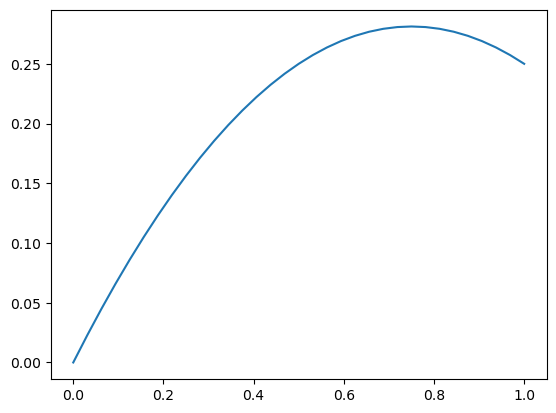

In [8]:
"""This demo program solves Poisson's equation in 1-D

    - d^2 u/ dx^2  = f(x)

on the unit interval with source f given by

    f(x) = 1

and boundary conditions given by

    u(0)= 0        for x = 0 
    du/dx = alpha for x=1
"""

# Modified from demo_poisson.py from the FEniCS demos


# Begin demo

from dolfin import *

# Create mesh and define function space
mesh = UnitIntervalMesh(32)
V = FunctionSpace(mesh, "Lagrange", 1)

# Define Dirichlet boundary (x = 0 )
def boundary(x):
    return x[0] < DOLFIN_EPS 

# Define boundary condition
# Dirichlet
u0 = Constant(0.0)
bc = DirichletBC(V, u0, boundary)
# Neumann:  du/dx = \alpha
alpha=Constant(-.25)

# Define variational problem
u = TrialFunction(V)
v = TestFunction(V)
f = Constant(1.)
a = v.dx(0)*u.dx(0)*dx
L = v*f*dx + v*alpha*ds

# Compute solution
u = Function(V)
solve(a == L, u, bc)

# Save solution in VTK format
file = File("poisson.pvd")
file << u


# Plot solution
#plot(u, interactive=True)
plot(u)

## Elemen Hingga dalam Dimensi yang Lebih Tinggi

Salah satu fitur indah dari FEniCS adalah memungkinkan Anda untuk menulis dan menyelesaikan PDE berdimensi lebih tinggi dengan sekitar jumlah pekerjaan yang sama seperti masalah 1-D. Sebagai contoh kita akan mempertimbangkan masalah berikut dan implementasi FEniCS-nya.

### Bentuk Kuat

Selesaikan masalah Poisson umum pada persegi panjang

$$
    -\nabla\cdot \alpha(x)\nabla u = f(x) \quad \mathrm{on} \quad \Omega=[0,2]\times[0,1]
$$

di mana $\alpha(x,y) > 0$ pada $\Omega$ ($\alpha=1$ adalah Poisson biasa) dan suku sumber

$$
    f(\boldsymbol{x}) = 10 \exp\left[ -((x - 1)^2 + (y - 1/2)^2)/0.02\right]
$$ 

dan syarat batas Dirichlet dalam arah x
$$
    u(0,y) = u(2,y) =0
$$

dan syarat batas Fluks Neumann pada batas y
$$
    \alpha(x)\nabla u\cdot\hat{n} = \sin(5x) \quad \mathrm{on} \quad y=0,1
$$
 
### Bentuk Lemah

Untuk membentuk bentuk lemah, kita memilih ruang fungsi $\cal V$, misalnya fungsi linear sepotong-sepotong di atas segitiga, dan menyelesaikan masalah variasional,

> Temukan $u$ dalam $\cal V$ sedemikian sehingga

$$ 
    -\int_\Omega v\nabla\cdot \alpha\nabla u dx = \int_\Omega vf dx
$$
untuk semua $v$ dalam $\cal V$.

Sekali lagi, mengintegrasikan masalah bilinear per bagian memberikan

\begin{align}
    -\int_\Omega v\nabla\cdot (\alpha \nabla u) dx &= \int_\Omega \nabla v\cdot (\alpha \nabla u) dx - \int_\Omega \nabla\cdot v(\alpha\nabla u) dx \\
    & = \int_\Omega \nabla v\cdot (\alpha \nabla u) dx - \int_{\partial\Omega}  v (\alpha\nabla u\cdot\hat{n}) ds \\
\end{align}

di mana kita telah menerapkan teorema divergensi Gauss pada suku terakhir untuk memindahkan integral ke batas di mana kita mengetahui syarat batas Neumann.

Dalam bahasa bentuk variasional, bentuk lemah dapat dideskripsikan sebagai $a(u,v) = L(v)$ di mana

\begin{align}
    a(u,v) &= \int_\Omega \nabla v\cdot \alpha \nabla u dx \\
    L(v) &= \int_\Omega vf dx + \int_{\partial\Omega}  v g ds \\
\end{align}

di mana

$$
    g(x,y) = \alpha\nabla u\cdot\hat{n} = \sin(5x)
$$

Luar biasa, kode FEniCS untuk masalah ini terlihat sangat mirip dengan apa yang baru saja kita tulis.
 


In [1]:
"""Program demo ini menyelesaikan persamaan Poisson dalam 2-D

    - div( alpha(x,y) * grad(u(x,y)) ) = f(x, y)

pada domain persegi panjang [0,2] x [0,1] dengan sumber f

    f(x, y) = 10 * exp(-((x-0.5)^2 + (y-0.5)^2) / 0.02)

dan syarat batas:
    u(x,y) = 0                            (Dirichlet) untuk x=0 atau x=2
    alpha * grad(u) . n = sin(5*x)        (Neumann)   untuk y=0 atau y=1
"""

from dolfin import *

# Membuat jaring persegi panjang pada [0,2]x[0,1]
# PERBAIKAN: gunakan Point() untuk titik sudut, bukan koordinat langsung
mesh = RectangleMesh(Point(0., 0.), Point(2., 1.), 64, 32)

# Ruang fungsi P1 (elemen Lagrange orde 1 / linear)
V = FunctionSpace(mesh, "Lagrange", 1)

# Batas Dirichlet: sisi kiri (x=0) dan sisi kanan (x=2)
def boundary(x):
    return x[0] < DOLFIN_EPS or x[0] > 2.0 - DOLFIN_EPS

# Syarat batas Dirichlet: u = 0
u0 = Constant(0.0)
bc = DirichletBC(V, u0, boundary)

# Fungsi percobaan (u) dan fungsi uji (v)
u = TrialFunction(V)
v = TestFunction(V)

# Koefisien difusi alpha = 1 (Poisson standar)
alpha = Constant(1.)

# Suku sumber: Gaussian terpusat di (0.5, 0.5)
# degree=2 wajib di FEniCS versi terbaru
f = Expression("10*exp(-(pow(x[0] - 0.5, 2) + pow(x[1] - 0.5, 2)) / 0.02)", degree=2)

# Fluks Neumann pada sisi atas (y=1) dan bawah (y=0)
g = Expression("sin(5*x[0])", degree=2)

# Bentuk bilinear: a(u,v) = integral( grad(v) . alpha * grad(u) )
a = inner(grad(v), alpha*grad(u))*dx

# Bentuk linear: L(v) = integral(f*v) + integral_batas(g*v)
L = v*f*dx + v*g*ds

# Selesaikan sistem A*w = f
u = Function(V)
solve(a == L, u, bc)

# Simpan ke format VTK (bisa dibuka dengan ParaView)
file = File("poisson.pvd")
file << u

# Tampilkan solusi
plot(u)

ModuleNotFoundError: No module named 'dolfin'

# Perangkat Lunak Lain

### Sumber Terbuka (*Open Source*)
- TerraFERMA
- FEAP
- ...

### Komersial
- Abaqus
- Comsol
- ...


# Melangkah Lebih Jauh dengan FEM: Daftar Tidak Lengkap

- Menambahkan ketergantungan waktu
- Elemen eksotis
- Stabilitas pilihan elemen
- Persamaan Hiperbolik dan Parabolik
- Persamaan Non-linear
- Pilihan solver yang efektif
- Multi-fisika
- dan seterusnya
